# DPO Preference Learning Results

Systematic hyperparameter sweep of DPO fine-tuning on Llama-3.1-8B-Instruct for harm classification.
Evaluated on three datasets: **Annotated Intents** (173), **WildGuardTest** (1,699), **XSTest** (450).

All runs use the same SFT adapter as the reference policy. Key dimensions explored:
- **β** (KL penalty): 0.1 → 0.7
- **Balancing**: undersampling (balanced pairs) vs weighted loss (hw=1.4, unbalanced pairs)
- **Epochs**: 1 → 4

In [8]:
import json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from sklearn.metrics import f1_score, precision_score, recall_score

sns.set_theme(style="whitegrid")
plt.rcParams.update({"figure.dpi": 120, "font.size": 11})

ROOT = Path("../..")
FIGS_DIR = Path("../../data/imgs")
FIGS_DIR.mkdir(parents=True, exist_ok=True)

In [9]:
def load_jsonl(path: Path) -> list[dict]:
    rows = []
    with open(path) as f:
        for line in f:
            line = line.strip()
            if line:
                try:
                    rows.append(json.loads(line))
                except json.JSONDecodeError:
                    pass
    return rows


def compute_metrics(path: Path) -> dict | None:
    """Return F1 Harmful (binary, pos_label=harmful), recall, precision and unparsed count."""
    if not path.exists():
        return None
    rows = load_jsonl(path)
    y_true, y_pred = [], []
    unparsed = 0
    for r in rows:
        true = r.get("true_harm") or r.get("true_harm_binary")
        pred = r.get("predicted_harm")
        if not true or not pred:
            unparsed += 1
            continue
        y_true.append(true.lower())
        y_pred.append(pred.lower())
    if not y_true:
        return None
    return {
        "f1":       f1_score(y_true, y_pred, pos_label="harmful", average="binary", zero_division=0),
        "rec":      recall_score(y_true, y_pred, pos_label="harmful", average="binary", zero_division=0),
        "prec":     precision_score(y_true, y_pred, pos_label="harmful", average="binary", zero_division=0),
        "n":        len(y_true),
        "unparsed": unparsed,
    }


# SFT Generation baseline — taken from baselines_results.ipynb (finetuned_generation condition).
# These use the full chat-template prompt; kept consistent with the reported baseline numbers.
SFT_BASELINE = {
    "ann": {"f1": 0.6358, "rec": 0.5714, "prec": 0.7164, "n": 173,  "unparsed": 0},
    "wgt": {"f1": 0.8639, "rec": 0.8210, "prec": 0.9116, "n": 1699, "unparsed": 0},
    "xst": {"f1": 0.9008, "rec": 0.8850, "prec": 0.9171, "n": 450,  "unparsed": 0},
}


def run_metrics(run_id: int | str) -> dict:
    """Load all three dataset metrics for a DPO run or 'sft' for the SFT baseline."""
    if run_id == "sft":
        return SFT_BASELINE
    else:
        base = ROOT / f"data/predictions/dpo_sweep/run_{run_id:02d}"
        return {
            "ann": compute_metrics(base / "test_predictions.jsonl"),
            "wgt": compute_metrics(base / "wildguardtest_predictions.jsonl"),
            "xst": compute_metrics(base / "xstest_predictions.jsonl"),
        }

In [10]:
# ── Full sweep config + results ────────────────────────────────────────────
CONFIGS = {
    # run: (group, beta, pairs, hw, epochs, ls, seed)
    1:  ("A",    0.50, "unbal", 1.0, 1, 0.00, 22),
    2:  ("B",    0.50, "bal",   1.0, 1, 0.00, 22),
    3:  ("B",    0.50, "bal",   1.0, 1, 0.10, 22),
    4:  ("B",    0.50, "unbal", 1.4, 1, 0.00, 22),
    5:  ("B",    0.50, "unbal", 1.4, 1, 0.10, 22),
    6:  ("C-us", 0.10, "bal",   1.0, 1, 0.00, 22),
    7:  ("C-us", 0.15, "bal",   1.0, 1, 0.00, 22),
    8:  ("C-us", 0.20, "bal",   1.0, 1, 0.00, 22),
    9:  ("C-us", 0.30, "bal",   1.0, 1, 0.00, 22),
    10: ("C-us", 0.40, "bal",   1.0, 1, 0.00, 22),
    11: ("C-us", 0.50, "bal",   1.0, 1, 0.00, 22),
    12: ("C-us", 0.60, "bal",   1.0, 1, 0.00, 22),
    13: ("C-us", 0.70, "bal",   1.0, 1, 0.00, 22),
    14: ("C-wl", 0.10, "unbal", 1.4, 1, 0.00, 22),
    15: ("C-wl", 0.15, "unbal", 1.4, 1, 0.00, 22),
    16: ("C-wl", 0.20, "unbal", 1.4, 1, 0.00, 22),
    17: ("C-wl", 0.30, "unbal", 1.4, 1, 0.00, 22),
    18: ("C-wl", 0.40, "unbal", 1.4, 1, 0.00, 22),
    19: ("C-wl", 0.50, "unbal", 1.4, 1, 0.00, 22),
    20: ("C-wl", 0.60, "unbal", 1.4, 1, 0.00, 22),
    21: ("C-wl", 0.70, "unbal", 1.4, 1, 0.00, 22),
    22: ("D-us", 0.50, "bal",   1.0, 2, 0.00, 22),
    23: ("D-us", 0.50, "bal",   1.0, 3, 0.00, 22),
    24: ("D-us", 0.50, "bal",   1.0, 1, 0.05, 22),
    25: ("D-us", 0.50, "bal",   1.0, 1, 0.00, 42),
    26: ("D-wl", 0.50, "unbal", 1.4, 2, 0.00, 22),
    27: ("D-wl", 0.50, "unbal", 1.4, 3, 0.00, 22),
    28: ("D-wl", 0.50, "unbal", 1.4, 1, 0.05, 22),
    29: ("D-wl", 0.50, "unbal", 1.4, 1, 0.00, 42),
    30: ("E",    0.10, "unbal", 1.4, 2, 0.00, 22),
    31: ("E",    0.20, "unbal", 1.4, 2, 0.00, 22),
    32: ("E",    0.30, "unbal", 1.4, 2, 0.00, 22),
    33: ("E",    0.10, "unbal", 1.4, 3, 0.00, 22),
    34: ("E",    0.20, "unbal", 1.4, 3, 0.00, 22),
    35: ("E",    0.50, "unbal", 1.4, 4, 0.00, 22),
}

rows = []
# SFT baseline
m = run_metrics("sft")
rows.append(dict(run=0, label="SFT", group="SFT", beta=float("nan"), pairs="—", hw=float("nan"),
                 epochs=float("nan"), ls=float("nan"),
                 ann_f1=m["ann"]["f1"], ann_rec=m["ann"]["rec"], ann_prec=m["ann"]["prec"],
                 wgt_f1=m["wgt"]["f1"], xst_f1=m["xst"]["f1"]))

for run_id, (group, beta, pairs, hw, epochs, ls, seed) in CONFIGS.items():
    m = run_metrics(run_id)
    if m["ann"] is None:
        continue
    label = f"Run {run_id:02d} (β={beta}, {epochs}e, {pairs}, hw={hw})"
    rows.append(dict(run=run_id, label=label, group=group, beta=beta, pairs=pairs, hw=hw,
                     epochs=epochs, ls=ls,
                     ann_f1=m["ann"]["f1"], ann_rec=m["ann"]["rec"], ann_prec=m["ann"]["prec"],
                     wgt_f1=m["wgt"]["f1"], xst_f1=m["xst"]["f1"]))

df = pd.DataFrame(rows)

# Reference values for findings section
sft_row   = df[df["run"] == 0].iloc[0]
run26_row = df[df["run"] == 26].iloc[0]
run27_row = df[df["run"] == 27].iloc[0]

fmt_nan = lambda x: f"{x:.2f}" if pd.notna(x) else "—"
fmt_hw  = lambda x: f"{x:.1f}" if pd.notna(x) else "—"
fmt_ep  = lambda x: str(int(x)) if pd.notna(x) else "—"

display_cols = ["run", "group", "beta", "pairs", "hw", "epochs", "ann_f1", "ann_rec", "wgt_f1", "xst_f1"]
styled = (
    df[display_cols]
    .rename(columns={"ann_f1": "Ann F1↑", "ann_rec": "Ann Rec", "wgt_f1": "WGT F1↑", "xst_f1": "XSTest F1↑"})
    .style
    .highlight_max(subset=["Ann F1↑", "WGT F1↑", "XSTest F1↑"], color="black")
    .format({"Ann F1↑": "{:.3f}", "Ann Rec": "{:.3f}", "WGT F1↑": "{:.3f}", "XSTest F1↑": "{:.3f}",
             "beta": fmt_nan, "hw": fmt_hw, "epochs": fmt_ep})
    .set_caption("All metrics are F1 Harmful (binary, positive class = harmful). Green = max, red = min Ann F1.")
)
styled

,run,group,beta,pairs,hw,epochs,Ann F1↑,Ann Rec,WGT F1↑,XSTest F1↑
0,0,SFT,—,—,—,—,0.636,0.571,0.864,0.901
1,1,A,0.50,unbal,1.0,1,0.582,0.464,0.829,0.893
2,2,B,0.50,bal,1.0,1,0.614,0.512,0.823,0.882
3,3,B,0.50,bal,1.0,1,0.574,0.440,0.818,0.889
4,4,B,0.50,unbal,1.4,1,0.580,0.452,0.830,0.891
5,5,B,0.50,unbal,1.4,1,0.544,0.410,0.826,0.888
6,6,C-us,0.10,bal,1.0,1,0.709,0.765,0.837,0.835
7,7,C-us,0.15,bal,1.0,1,0.690,0.699,0.835,0.854
8,8,C-us,0.20,bal,1.0,1,0.662,0.622,0.837,0.866
9,9,C-us,0.30,bal,1.0,1,0.680,0.614,0.840,0.869


## Main Comparison: SFT vs Best DPO Configurations

Selected runs that represent key findings across all three evaluation datasets.

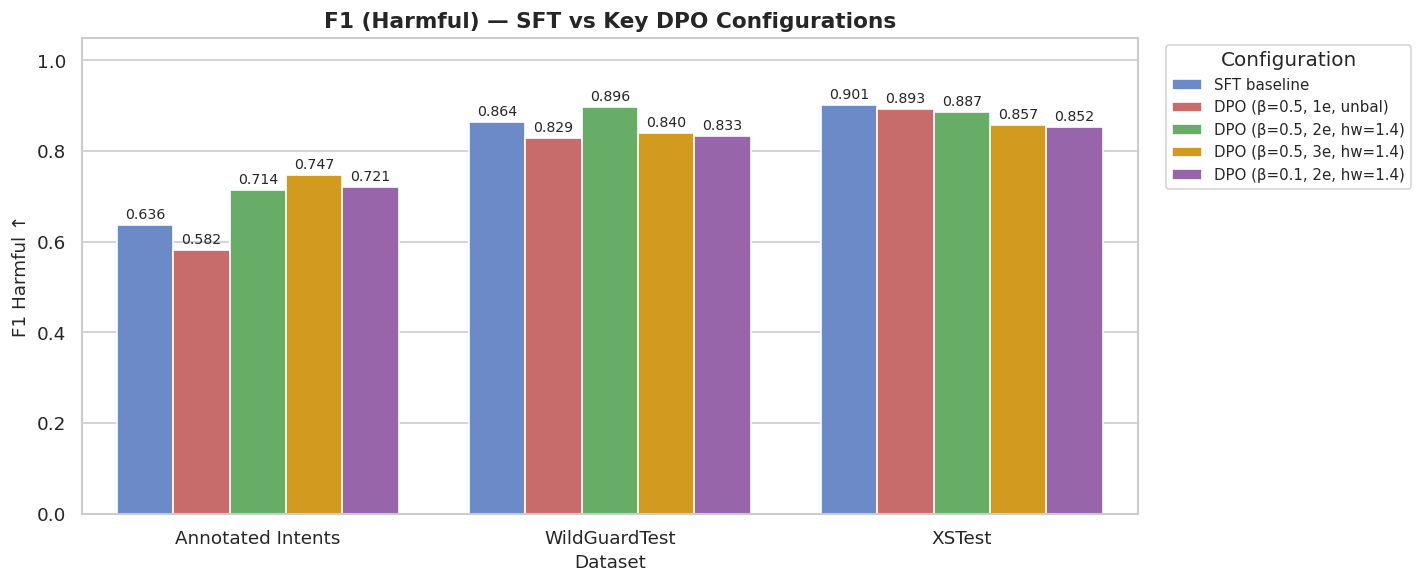

In [11]:
# Key runs to compare — one representative per finding
KEY_RUNS = {
    "SFT baseline":              0,
    "DPO (β=0.5, 1e, unbal)":   1,   # Group A — original failed run
    "DPO (β=0.5, 2e, hw=1.4)":  26,  # Best overall balance
    "DPO (β=0.5, 3e, hw=1.4)":  27,  # Best in-domain (Ann)
    "DPO (β=0.1, 2e, hw=1.4)":  30,  # Best Ann in Group E
}

DATASETS   = ["ann_f1", "wgt_f1", "xst_f1"]
DSET_NAMES = ["Annotated Intents", "WildGuardTest", "XSTest"]

# Build plot dataframe
plot_rows = []
for label, run_id in KEY_RUNS.items():
    row = df[df["run"] == run_id].iloc[0]
    for col, name in zip(DATASETS, DSET_NAMES):
        plot_rows.append({"Model": label, "Dataset": name, "F1 Harmful": row[col]})
df_plot = pd.DataFrame(plot_rows)

COLORS = {
    "SFT baseline":              "#5c85d6",
    "DPO (β=0.5, 1e, unbal)":   "#d65c5c",
    "DPO (β=0.5, 2e, hw=1.4)":  "#5cb85c",
    "DPO (β=0.5, 3e, hw=1.4)":  "#f0a500",
    "DPO (β=0.1, 2e, hw=1.4)":  "#9b59b6",
}

fig, ax = plt.subplots(figsize=(12, 5))
sns.barplot(data=df_plot, x="Dataset", y="F1 Harmful", hue="Model",
            palette=COLORS, ax=ax)
for container in ax.containers:
    ax.bar_label(container, fmt="%.3f", fontsize=8.5, padding=2)

ax.set_ylim(0, 1.05)
ax.set_title("F1 (Harmful) — SFT vs Key DPO Configurations", fontsize=13, fontweight="bold")
ax.set_xlabel("Dataset", fontsize=11)
ax.set_ylabel("F1 Harmful ↑", fontsize=11)
ax.legend(title="Configuration", bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=9)
plt.tight_layout()
fig.savefig(FIGS_DIR / "dpo_main_comparison.pdf", bbox_inches="tight")
plt.show()

## β Sweep: Undersampling vs Weighted Loss (1 Epoch)

Groups C-us (balanced pairs, hw=1.0) and C-wl (unbalanced pairs, hw=1.4) sweep β from 0.1 to 0.7.

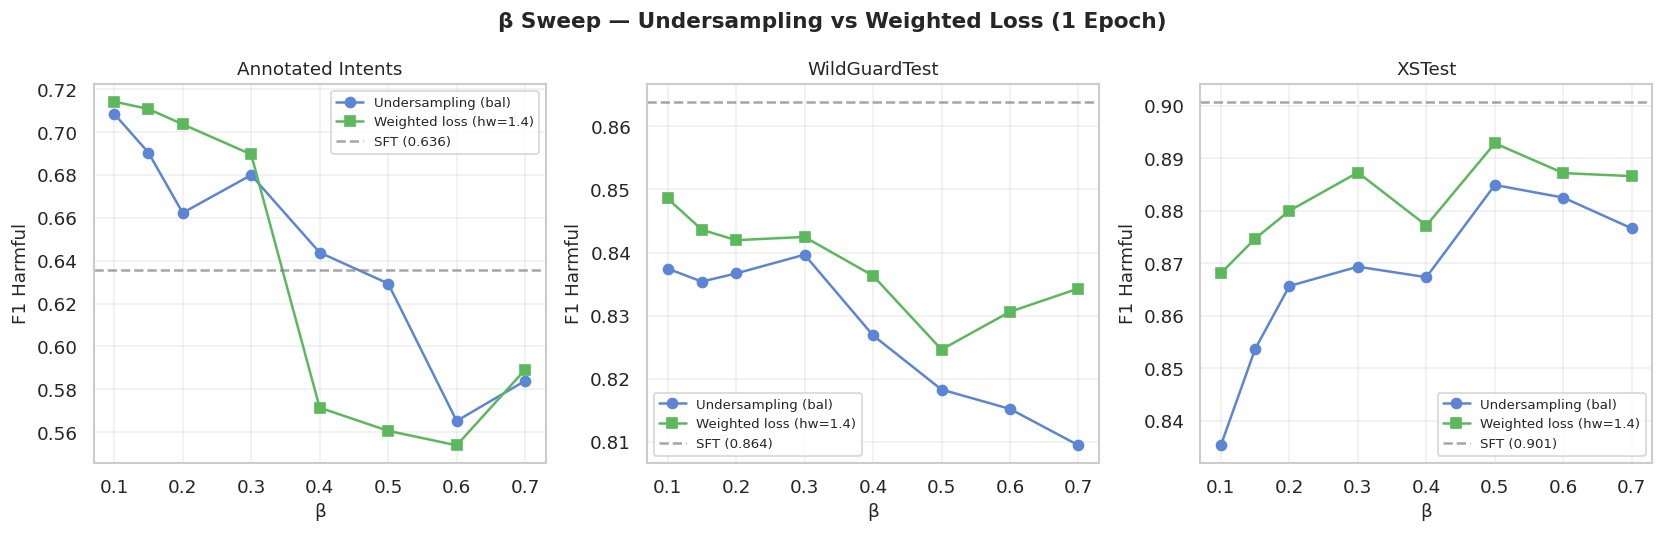

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4.5), sharey=False)

df_cus = df[df["group"] == "C-us"].sort_values("beta")
df_cwl = df[df["group"] == "C-wl"].sort_values("beta")
sft_row = df[df["run"] == 0].iloc[0]

for ax, col, title in zip(axes, DATASETS, DSET_NAMES):
    ax.plot(df_cus["beta"], df_cus[col], marker="o", label="Undersampling (bal)",   color="#5c85d6")
    ax.plot(df_cwl["beta"], df_cwl[col], marker="s", label="Weighted loss (hw=1.4)", color="#5cb85c")
    ax.axhline(sft_row[col], linestyle="--", color="gray", alpha=0.7, label=f"SFT ({sft_row[col]:.3f})")
    ax.set_xlabel("β", fontsize=11)
    ax.set_ylabel("F1 Harmful", fontsize=11)
    ax.set_title(title, fontsize=11)
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

plt.suptitle("β Sweep — Undersampling vs Weighted Loss (1 Epoch)", fontsize=13, fontweight="bold")
plt.tight_layout()
fig.savefig(FIGS_DIR / "dpo_beta_sweep.pdf", bbox_inches="tight")
plt.show()

## Effect of Training Epochs (hw=1.4, unbalanced pairs)

Runs with the weighted loss strategy across 1–4 epochs. β=0.5 unless otherwise noted.

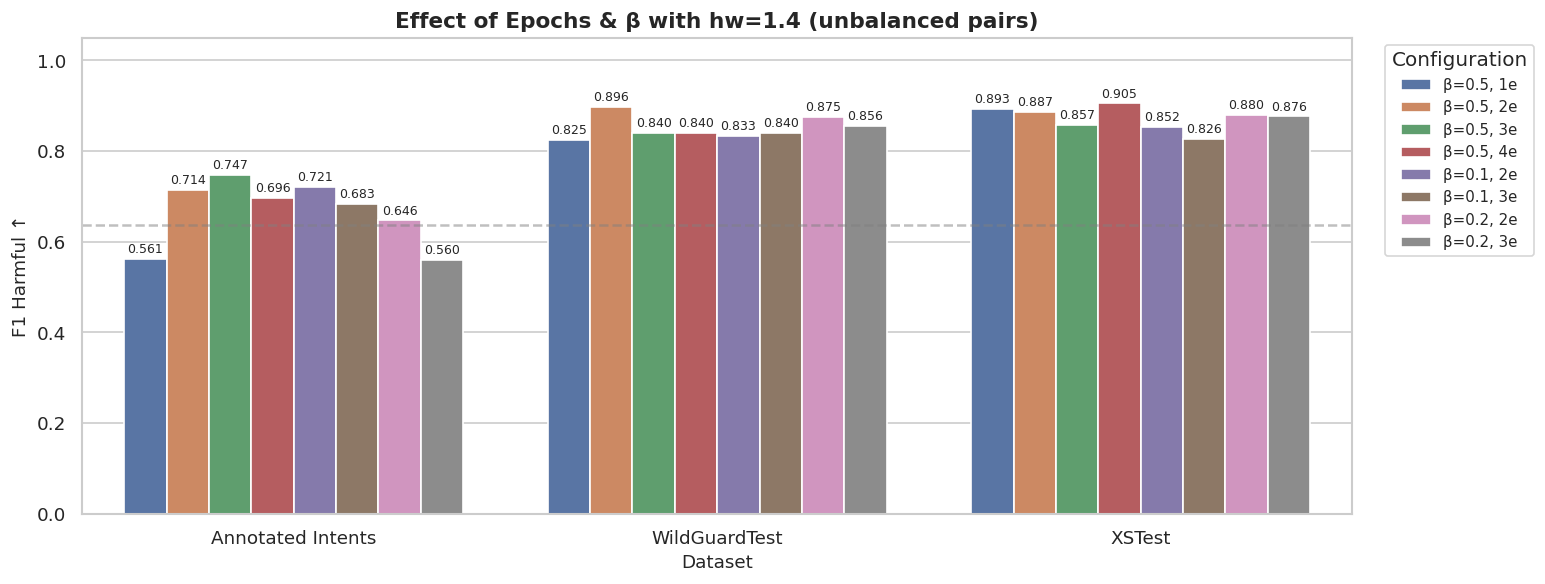

In [13]:
# Epoch comparison: β=0.5 with hw=1.4 (runs 4/19, 26, 27, 35) + low-β at 2/3 epochs
EPOCH_RUNS = {
    "β=0.5, 1e": 19,
    "β=0.5, 2e": 26,
    "β=0.5, 3e": 27,
    "β=0.5, 4e": 35,
    "β=0.1, 2e": 30,
    "β=0.1, 3e": 33,
    "β=0.2, 2e": 31,
    "β=0.2, 3e": 34,
}

epoch_rows = []
for label, run_id in EPOCH_RUNS.items():
    row = df[df["run"] == run_id].iloc[0]
    for col, name in zip(DATASETS, DSET_NAMES):
        epoch_rows.append({"Config": label, "Dataset": name, "F1 Harmful": row[col]})
df_epochs = pd.DataFrame(epoch_rows)

fig, ax = plt.subplots(figsize=(13, 5))
sns.barplot(data=df_epochs, x="Dataset", y="F1 Harmful", hue="Config", ax=ax)
for container in ax.containers:
    ax.bar_label(container, fmt="%.3f", fontsize=7.5, padding=2)

ax.axhline(sft_row["ann_f1"], linestyle="--", color="gray", alpha=0.5)  # rough ref
ax.set_ylim(0, 1.05)
ax.set_title("Effect of Epochs & β with hw=1.4 (unbalanced pairs)", fontsize=13, fontweight="bold")
ax.set_xlabel("Dataset", fontsize=11)
ax.set_ylabel("F1 Harmful ↑", fontsize=11)
ax.legend(title="Configuration", bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=9)
plt.tight_layout()
fig.savefig(FIGS_DIR / "dpo_epochs_comparison.pdf", bbox_inches="tight")
plt.show()

## Top Configurations per Metric

In [14]:
print("── Top 5 by Annotated Intents F1 ──")
display(df[df["run"] > 0][["run","group","beta","pairs","hw","epochs","ann_f1","wgt_f1","xst_f1"]]
        .nlargest(5, "ann_f1")
        .style.format({"ann_f1":"{:.3f}","wgt_f1":"{:.3f}","xst_f1":"{:.3f}",
                        "beta":lambda x:f"{x:.2f}","hw":lambda x:f"{x:.1f}","epochs":lambda x:str(int(x))}))

print("\n── Top 5 by WildGuardTest F1 ──")
display(df[df["run"] > 0][["run","group","beta","pairs","hw","epochs","ann_f1","wgt_f1","xst_f1"]]
        .nlargest(5, "wgt_f1")
        .style.format({"ann_f1":"{:.3f}","wgt_f1":"{:.3f}","xst_f1":"{:.3f}",
                        "beta":lambda x:f"{x:.2f}","hw":lambda x:f"{x:.1f}","epochs":lambda x:str(int(x))}))

── Top 5 by Annotated Intents F1 ──


,run,group,beta,pairs,hw,epochs,ann_f1,wgt_f1,xst_f1
27,27,D-wl,0.50,unbal,1.4,3,0.747,0.840,0.857
30,30,E,0.10,unbal,1.4,2,0.721,0.833,0.852
14,14,C-wl,0.10,unbal,1.4,1,0.714,0.849,0.868
26,26,D-wl,0.50,unbal,1.4,2,0.714,0.896,0.887
15,15,C-wl,0.15,unbal,1.4,1,0.711,0.844,0.875



── Top 5 by WildGuardTest F1 ──


,run,group,beta,pairs,hw,epochs,ann_f1,wgt_f1,xst_f1
26,26,D-wl,0.50,unbal,1.4,2,0.714,0.896,0.887
31,31,E,0.20,unbal,1.4,2,0.646,0.875,0.880
25,25,D-us,0.50,bal,1.0,1,0.710,0.862,0.882
23,23,D-us,0.50,bal,1.0,3,0.671,0.859,0.897
29,29,D-wl,0.50,unbal,1.4,1,0.662,0.859,0.881


## Key Findings
> All numbers are **F1 Harmful** (binary, positive class = harmful).

| # | Finding |
|---|---------|
| 1 | **β=0.5 with 1 epoch fails** — harmful recall collapses regardless of balancing strategy (runs 1–5). The SFT prior is too strong to overcome in a single pass. |
| 2 | **Weighted loss (hw=1.4) outperforms undersampling** — keeps all 828 pairs and amplifies harmful gradients, vs undersampling which discards 92 pairs and loses signal. |
| 3 | **More epochs unlock DPO gains** — run 27 (β=0.5, 3 epochs, hw=1.4) achieves the highest in-domain F1 Harmful (see table). Without weighted loss, 3 epochs still underperforms SFT. |
| 4 | **In-domain vs OOD trade-off** — 3 epochs improves Ann F1 Harmful but loses WGT and XSTest vs 2 epochs. Run 26 (2 epochs, hw=1.4) is the best overall balance. |
| 5 | **Lower β at 2 epochs does not improve on run 26** — run 30 (β=0.1, 2e) peaks in Ann but WGT drops significantly. Neither beats run 26 overall. |
| 6 | **4 epochs (run 35) achieves the best XSTest F1 Harmful** at the cost of Ann, confirming increasing OOD overfitting with more training. |